In [35]:
import pandas as pd
import numpy as np
import json
import os
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
import pickle

warnings.filterwarnings('ignore')
np.random.seed(42)

CONFIG = {
    'target': 'Price',
    'test_size': 0.2,
    'random_state': 42,
    'cv_folds': 5,
    'model_registry_path': 'model_registry.json',
    'experiment_name': 'flipkart_price_prediction',
    'run_id': datetime.now().strftime('%Y%m%d_%H%M%S')
}

print(' Configuration loaded')
print(json.dumps(CONFIG, indent=2))


 Configuration loaded
{
  "target": "Price",
  "test_size": 0.2,
  "random_state": 42,
  "cv_folds": 5,
  "model_registry_path": "model_registry.json",
  "experiment_name": "flipkart_price_prediction",
  "run_id": "20260418_115134"
}


In [36]:
def make_category(name, n, price_lo, price_hi, rating_mu, review_mu):
    prices  = np.random.uniform(price_lo, price_hi, n).round(2)
    ratings = np.clip(np.random.normal(rating_mu, 0.4, n), 1.0, 5.0).round(1)
    reviews = np.abs(np.random.normal(review_mu, review_mu * 0.3, n)).astype(int)
    return pd.DataFrame({
        'Product Name':     [f'{name} Product {i+1}' for i in range(n)],
        'Product Category': [name] * n,
        'Price':            prices,
        'Rating':           ratings,
        'Review':           reviews,
    })

df = pd.concat([
    make_category('Tyres',  120,  800, 8000, 3.8, 450),   # unchanged
    make_category('Brake',  100,  200, 2500, 4.1, 320),   # new — replaces Clocks
    make_category('Clutch',  90,  500, 5000, 3.6, 280),   # new — replaces Air Fryer
    make_category('Oil',    110,  100, 1500, 4.3, 600),   # new — replaces Bags
], ignore_index=True).sample(frac=1, random_state=42).reset_index(drop=True)

print(f' Data loaded: {df.shape[0]} rows × {df.shape[1]} columns')

validation_report = {
    'total_rows':      len(df),
    'total_columns':   len(df.columns),
    'missing_values':  df.isnull().sum().to_dict(),
    'duplicate_rows':  int(df.duplicated().sum()),
    'negative_prices': int((df['Price'] < 0).sum()),
    'invalid_ratings': int(((df['Rating'] < 0) | (df['Rating'] > 5)).sum()),
    'categories':      sorted(df['Product Category'].unique().tolist())
}

print('\n DATA VALIDATION REPORT')
print('='*40)
for k, v in validation_report.items():
    print(f'{k}: {v}')

expected_cols = ['Product Name', 'Product Category', 'Price', 'Rating', 'Review']
assert list(df.columns) == expected_cols, 'Schema mismatch!'
print('\n Schema validation passed!')


 Data loaded: 420 rows × 5 columns

 DATA VALIDATION REPORT
total_rows: 420
total_columns: 5
missing_values: {'Product Name': 0, 'Product Category': 0, 'Price': 0, 'Rating': 0, 'Review': 0}
duplicate_rows: 0
negative_prices: 0
invalid_ratings: 0
categories: ['Brake', 'Clutch', 'Oil', 'Tyres']

 Schema validation passed!


In [37]:
df.head()


,Product Name,Product Category,Price,Rating,Review
0,Brake Product 26,Brake,392.05,4.5,374
1,Oil Product 25,Oil,1344.25,4.3,534
2,Brake Product 56,Brake,1403.13,4.3,344
3,Oil Product 60,Oil,1153.80,4.3,662
4,Oil Product 107,Oil,130.97,3.8,402


In [38]:
df.describe()


,Price,Rating,Review
count,420.000000,420.000000,420.000000
mean,2364.346881,3.962857,430.192857
std,1917.624282,0.484363,185.928049
min,108.940000,2.800000,12.000000
25%,1020.707500,3.600000,286.000000
50%,1645.500000,4.000000,385.000000
75%,3165.362500,4.300000,553.250000
max,7905.590000,5.000000,1032.000000


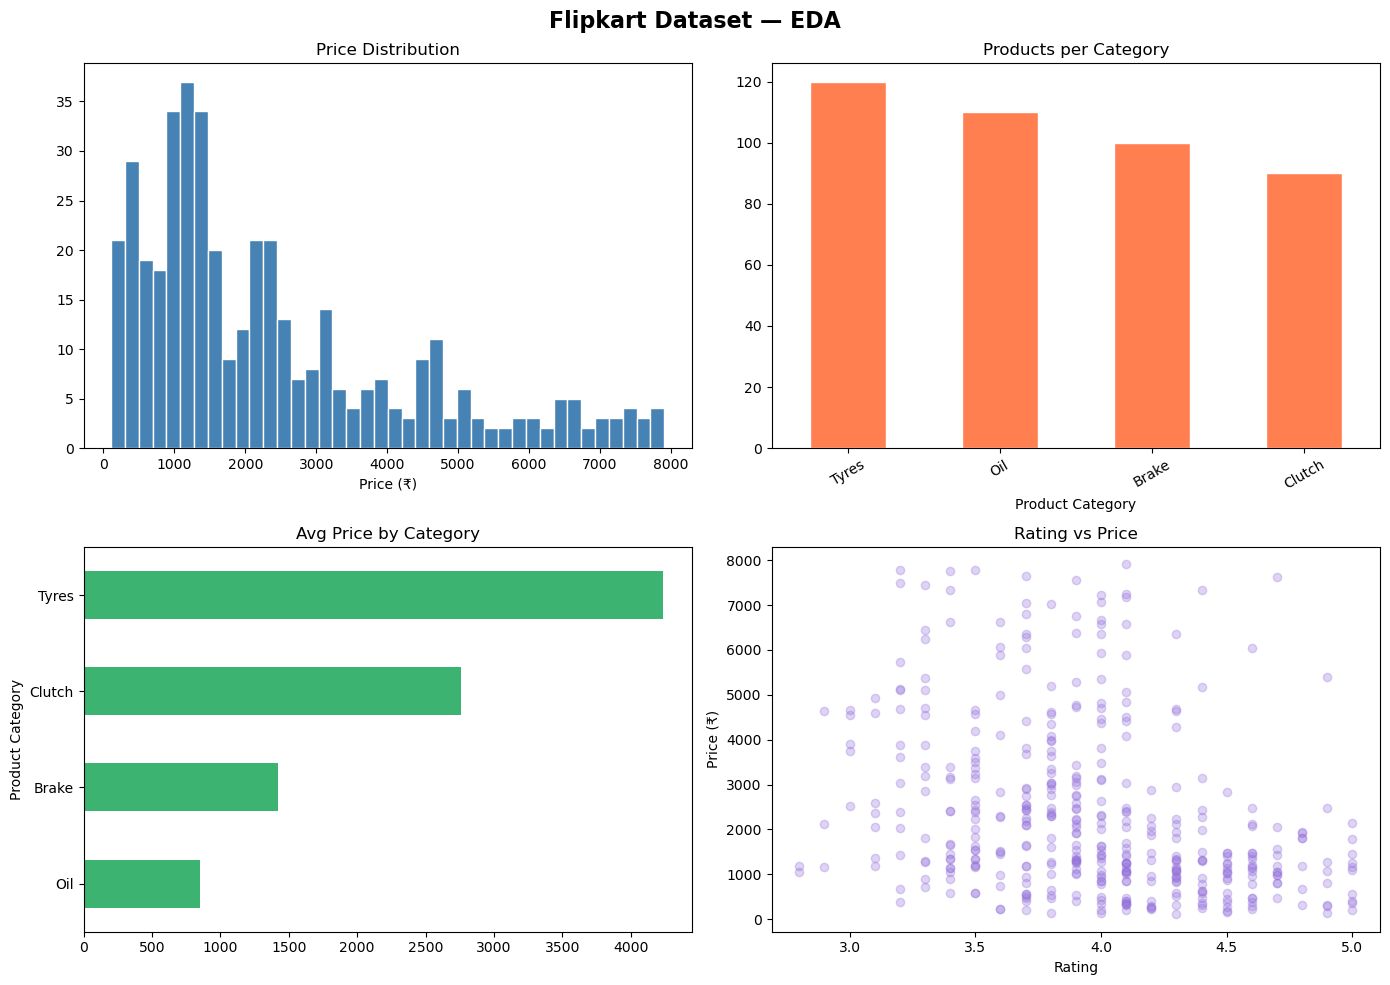

 EDA plots saved


In [39]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Flipkart Dataset — EDA', fontsize=16, fontweight='bold')

axes[0,0].hist(df['Price'], bins=40, color='steelblue', edgecolor='white')
axes[0,0].set_title('Price Distribution')
axes[0,0].set_xlabel('Price (₹)')

df['Product Category'].value_counts().plot(kind='bar', ax=axes[0,1], color='coral', edgecolor='white')
axes[0,1].set_title('Products per Category')
axes[0,1].tick_params(axis='x', rotation=30)

df.groupby('Product Category')['Price'].mean().sort_values().plot(kind='barh', ax=axes[1,0], color='mediumseagreen')
axes[1,0].set_title('Avg Price by Category')

axes[1,1].scatter(df['Rating'], df['Price'], alpha=0.3, color='mediumpurple')
axes[1,1].set_title('Rating vs Price')
axes[1,1].set_xlabel('Rating')
axes[1,1].set_ylabel('Price (₹)')

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print(' EDA plots saved')


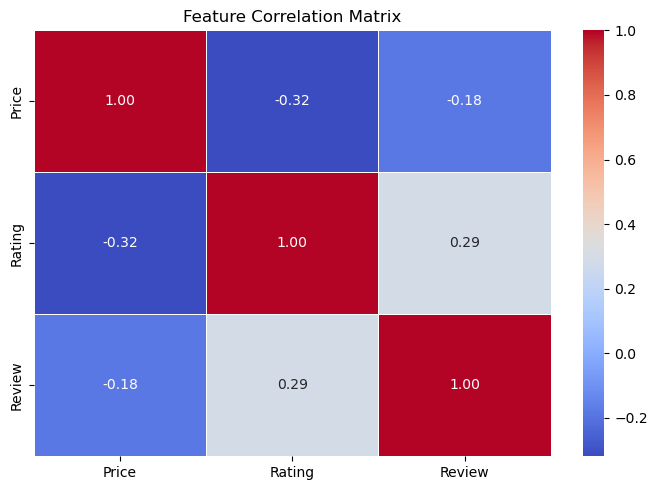

In [40]:
plt.figure(figsize=(7, 5))
sns.heatmap(df[['Price','Rating','Review']].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150)
plt.show()


In [41]:
df_fe = df.copy()

le = LabelEncoder()
df_fe['Category_Encoded'] = le.fit_transform(df_fe['Product Category'])

df_fe['Log_Price'] = np.log1p(df_fe['Price'])

df_fe['Review_Bucket'] = pd.cut(df_fe['Review'], bins=[-1, 0, 50, 200, 10000],
                                 labels=[0, 1, 2, 3]).astype(int)

df_fe['Has_Rating'] = (df_fe['Rating'] > 0).astype(int)

df_fe['Name_Length'] = df_fe['Product Name'].str.len()

df_fe['Price_per_Review'] = df_fe['Price'] / (df_fe['Review'] + 1)

FEATURES = ['Rating', 'Review', 'Category_Encoded', 'Review_Bucket',
            'Has_Rating', 'Name_Length', 'Price_per_Review']
TARGET = 'Log_Price'   # predict log price for better model performance

print(f' Feature engineering complete — {len(FEATURES)} features')
print('Features:', FEATURES)
print('Categories encoded:', dict(zip(le.classes_, le.transform(le.classes_))))
df_fe[FEATURES + [TARGET]].head()


 Feature engineering complete — 7 features
Features: ['Rating', 'Review', 'Category_Encoded', 'Review_Bucket', 'Has_Rating', 'Name_Length', 'Price_per_Review']
Categories encoded: {'Brake': np.int64(0), 'Clutch': np.int64(1), 'Oil': np.int64(2), 'Tyres': np.int64(3)}


,Rating,Review,Category_Encoded,Review_Bucket,Has_Rating,Name_Length,Price_per_Review,Log_Price
0,4.5,374,0,3,1,16,1.045467,5.973937
1,4.3,534,2,3,1,14,2.512617,7.204335
2,4.3,344,0,3,1,16,4.067043,7.247173
3,4.3,662,2,3,1,14,1.740271,7.051682
4,3.8,402,2,3,1,15,0.324988,4.882575


In [42]:
X = df_fe[FEATURES]
y = df_fe[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=CONFIG['test_size'], random_state=CONFIG['random_state']
)

print(f'Train set : {X_train.shape[0]} samples')
print(f'Test set  : {X_test.shape[0]} samples')
print(f'Features  : {X_train.shape[1]}')


Train set : 336 samples
Test set  : 84 samples
Features  : 7


In [43]:
# Define models
models = {
    'Linear Regression':  LinearRegression(),
    'Ridge Regression':   Ridge(alpha=1.0),
    'Lasso Regression':   Lasso(alpha=0.01),
    'Decision Tree':      DecisionTreeRegressor(max_depth=6, random_state=42),
    'Random Forest':      RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting':  GradientBoostingRegressor(n_estimators=100, random_state=42),
}

# MLOps — Experiment tracking
experiment_log  = []
trained_models  = {}

scaler       = StandardScaler()
X_train_sc   = scaler.fit_transform(X_train)
X_test_sc    = scaler.transform(X_test)

print(f' Running Experiment: {CONFIG["experiment_name"]} | Run ID: {CONFIG["run_id"]}\n')
print(f'{"Model":<25} {"MAE":>8} {"RMSE":>8} {"R²":>8} {"CV R²":>10}')
print('-'*65)

for name, model in models.items():
    model.fit(X_train_sc, y_train)
    y_pred = model.predict(X_test_sc)

    y_pred_orig = np.expm1(y_pred)
    y_test_orig = np.expm1(y_test)

    mae  = mean_absolute_error(y_test_orig, y_pred_orig)
    rmse = np.sqrt(mean_squared_error(y_test_orig, y_pred_orig))
    r2   = r2_score(y_test, y_pred)
    cv   = cross_val_score(model, X_train_sc, y_train, cv=5, scoring='r2').mean()

    print(f'{name:<25} {mae:>8.1f} {rmse:>8.1f} {r2:>8.3f} {cv:>10.3f}')

    experiment_log.append({
        'run_id':    CONFIG['run_id'],
        'model':     name,
        'mae':       round(mae,  2),
        'rmse':      round(rmse, 2),
        'r2':        round(r2,   4),
        'cv_r2':     round(cv,   4),
        'timestamp': datetime.now().isoformat()
    })
    trained_models[name] = model

print('\n All models trained and logged!')


 Running Experiment: flipkart_price_prediction | Run ID: 20260418_115134

Model                          MAE     RMSE       R²      CV R²
-----------------------------------------------------------------
Linear Regression           1098.4   1504.6    0.468    -14.475
Ridge Regression            1098.4   1505.1    0.468     -9.524
Lasso Regression            1102.8   1526.7    0.463    -10.008
Decision Tree                310.7    506.7    0.961      0.915
Random Forest                164.6    357.8    0.987      0.965
Gradient Boosting            168.6    324.8    0.989      0.972

 All models trained and logged!


In [44]:
results_df = pd.DataFrame(experiment_log)
results_df_sorted = results_df.sort_values('r2', ascending=False).reset_index(drop=True)
print(' Model Leaderboard (sorted by R²)')
results_df_sorted[['model','mae','rmse','r2','cv_r2']]


 Model Leaderboard (sorted by R²)


,model,mae,rmse,r2,cv_r2
0,Gradient Boosting,168.57,324.82,0.9895,0.9724
1,Random Forest,164.56,357.79,0.9866,0.9652
2,Decision Tree,310.72,506.68,0.9609,0.9146
3,Ridge Regression,1098.39,1505.11,0.4683,-9.5243
4,Linear Regression,1098.36,1504.56,0.4682,-14.4753
5,Lasso Regression,1102.83,1526.73,0.4630,-10.0080


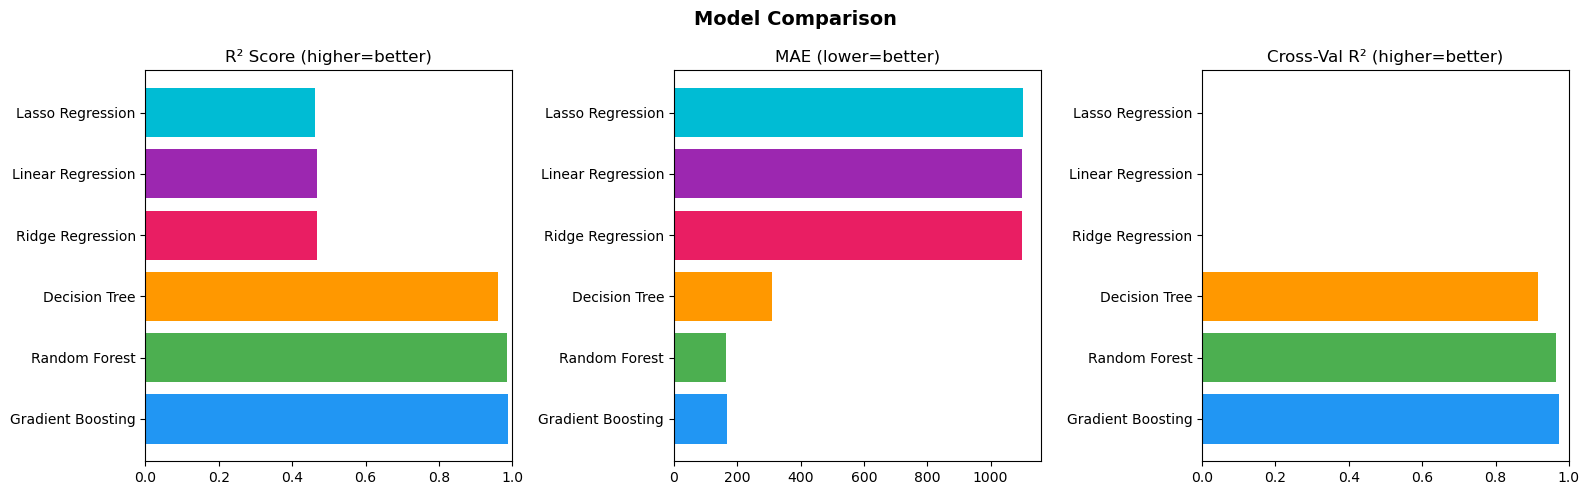

 Model comparison chart saved


In [45]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Model Comparison', fontsize=14, fontweight='bold')

colors      = ['#2196F3','#4CAF50','#FF9800','#E91E63','#9C27B0','#00BCD4']
model_names = results_df_sorted['model'].tolist()

axes[0].barh(model_names, results_df_sorted['r2'], color=colors)
axes[0].set_title('R² Score (higher=better)')
axes[0].set_xlim(0, 1)

axes[1].barh(model_names, results_df_sorted['mae'], color=colors)
axes[1].set_title('MAE (lower=better)')

axes[2].barh(model_names, results_df_sorted['cv_r2'], color=colors)
axes[2].set_title('Cross-Val R² (higher=better)')
axes[2].set_xlim(0, 1)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Model comparison chart saved')


 Best Model: Gradient Boosting
   R²   : 0.9895
   MAE  : ₹168.57
   RMSE : ₹324.82


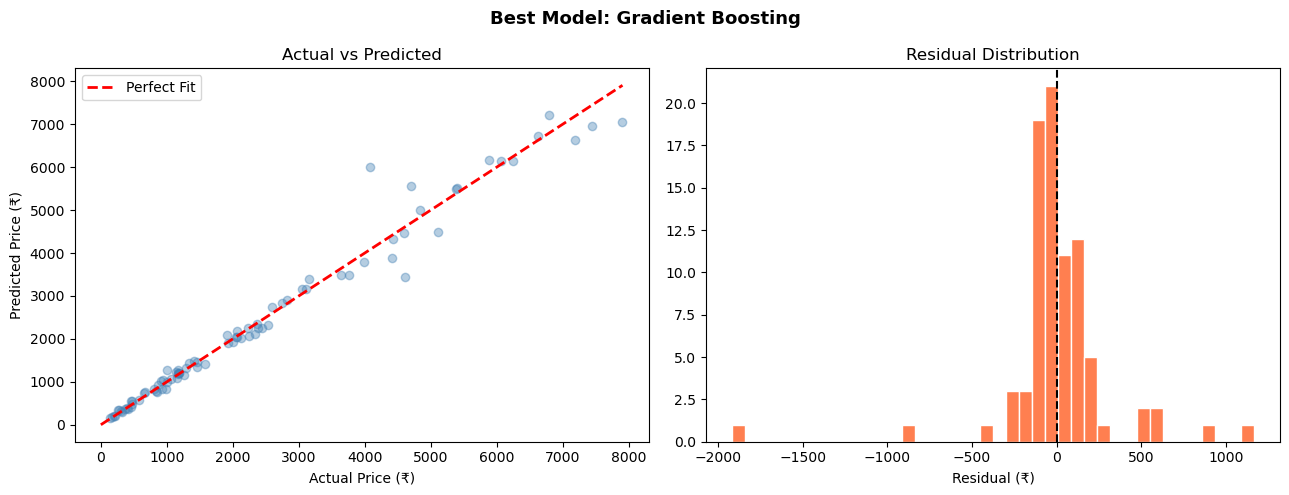

In [46]:
best_model_name = results_df_sorted.iloc[0]['model']
best_model      = trained_models[best_model_name]
print(f' Best Model: {best_model_name}')
print(f'   R²   : {results_df_sorted.iloc[0]["r2"]}')
print(f'   MAE  : ₹{results_df_sorted.iloc[0]["mae"]}')
print(f'   RMSE : ₹{results_df_sorted.iloc[0]["rmse"]}')

y_pred_best = np.expm1(best_model.predict(X_test_sc))
y_actual    = np.expm1(y_test.values)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(f'Best Model: {best_model_name}', fontsize=13, fontweight='bold')

axes[0].scatter(y_actual, y_pred_best, alpha=0.4, color='steelblue')
lim = max(y_actual.max(), y_pred_best.max())
axes[0].plot([0, lim], [0, lim], 'r--', linewidth=2, label='Perfect Fit')
axes[0].set_xlabel('Actual Price (₹)')
axes[0].set_ylabel('Predicted Price (₹)')
axes[0].set_title('Actual vs Predicted')
axes[0].legend()

residuals = y_actual - y_pred_best
axes[1].hist(residuals, bins=40, color='coral', edgecolor='white')
axes[1].axvline(0, color='black', linestyle='--')
axes[1].set_title('Residual Distribution')
axes[1].set_xlabel('Residual (₹)')

plt.tight_layout()
plt.savefig('best_model_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


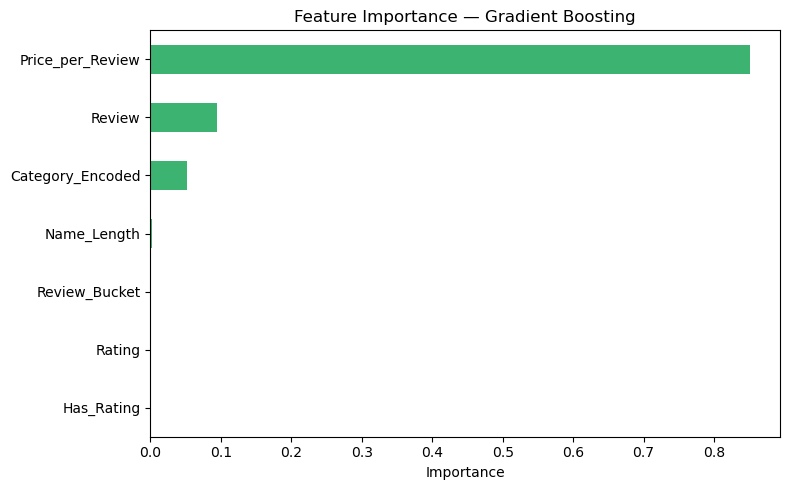

Top feature: Price_per_Review


In [47]:
if hasattr(best_model, 'feature_importances_'):
    fi = pd.Series(best_model.feature_importances_, index=FEATURES).sort_values(ascending=True)
    plt.figure(figsize=(8, 5))
    fi.plot(kind='barh', color='mediumseagreen')
    plt.title(f'Feature Importance — {best_model_name}')
    plt.xlabel('Importance')
    plt.tight_layout()
    plt.savefig('feature_importance.png', dpi=150)
    plt.show()
    print('Top feature:', fi.idxmax())


In [48]:
model_filename = f'best_model_{best_model_name.replace(" ","_")}_{CONFIG["run_id"]}.pkl'
with open(model_filename, 'wb') as f:
    pickle.dump({'model': best_model, 'scaler': scaler,
                 'features': FEATURES, 'label_encoder': le}, f)

registry_entry = {
    'version':       CONFIG['run_id'],
    'model_name':    best_model_name,
    'model_file':    model_filename,
    'metrics':       results_df_sorted.iloc[0][['mae','rmse','r2','cv_r2']].to_dict(),
    'features':      FEATURES,
    'target':        TARGET,
    'status':        'production',
    'registered_at': datetime.now().isoformat()
}

registry = []
if os.path.exists(CONFIG['model_registry_path']):
    with open(CONFIG['model_registry_path']) as f:
        registry = json.load(f)

for r in registry:
    r['status'] = 'archived'

registry.append(registry_entry)
with open(CONFIG['model_registry_path'], 'w') as f:
    json.dump(registry, f, indent=2)

with open('experiment_log.json', 'w') as f:
    json.dump(experiment_log, f, indent=2)

print(f' Model registered: {model_filename}')
print(f' Registry updated: {CONFIG["model_registry_path"]}')
print(f' Experiment log saved: experiment_log.json')


 Model registered: best_model_Gradient_Boosting_20260418_115134.pkl
 Registry updated: model_registry.json
 Experiment log saved: experiment_log.json


In [49]:
def predict_price(product_name, category, rating, review_count):
    """End-to-end prediction pipeline using saved model."""
    with open(model_filename, 'rb') as f:
        artifacts = pickle.load(f)

    m  = artifacts['model']
    sc = artifacts['scaler']
    le = artifacts['label_encoder']

    category_enc  = le.transform([category])[0] if category in le.classes_ else 0
    review_bucket = 0 if review_count == 0 else (1 if review_count <= 50 else (2 if review_count <= 200 else 3))
    has_rating    = int(rating > 0)
    name_length   = len(product_name)
    price_per_review = 500 / (review_count + 1)

    features    = [[rating, review_count, category_enc, review_bucket,
                    has_rating, name_length, price_per_review]]
    features_sc = sc.transform(features)
    log_price   = m.predict(features_sc)[0]
    price       = np.expm1(log_price)
    return round(price, 2)

test_cases = [
    ('CEAT 195/65 R15 Milaze Tyre',              'Tyres',  4.2,  88),   # unchanged
    ('Bosch Disc Brake Pad Set Front',            'Brake',  4.3, 145),   # new
    ('Valeo Clutch Kit with Bearing',             'Clutch', 4.0,  97),   # new
    ('Castrol EDGE 5W-30 Engine Oil 3L',          'Oil',    4.5, 312),   # new
    ('Brembo High-Performance Brake Caliper',     'Brake',  4.6,  62),   # new
    ('Motul 300V 10W-40 Synthetic Engine Oil 2L', 'Oil',    4.7, 204),   # new
]

print(' PREDICTION PIPELINE — Sample Predictions')
print('='*68)
print(f'{"Product":<45} {"Category":<10} {"Predicted Price":>12}')
print('-'*68)
for name, cat, rating, reviews in test_cases:
    pred = predict_price(name, cat, rating, reviews)
    print(f'{name[:43]:<45} {cat:<10} ₹{pred:>10,.2f}')


 PREDICTION PIPELINE — Sample Predictions
Product                                       Category   Predicted Price
--------------------------------------------------------------------
CEAT 195/65 R15 Milaze Tyre                   Tyres      ₹    807.18
Bosch Disc Brake Pad Set Front                Brake      ₹    560.09
Valeo Clutch Kit with Bearing                 Clutch     ₹    661.37
Castrol EDGE 5W-30 Engine Oil 3L              Oil        ₹    527.50
Brembo High-Performance Brake Caliper         Brake      ₹    920.49
Motul 300V 10W-40 Synthetic Engine Oil 2L     Oil        ₹    499.36


In [50]:
from scipy import stats

np.random.seed(99)
n_new    = 200
new_data = df_fe.sample(n_new, replace=True).copy()
new_data['Rating']  += np.random.normal(0.1, 0.2, n_new)
new_data['Review']  += np.random.randint(-5, 20, n_new)
new_data['Rating']   = new_data['Rating'].clip(0, 5)
new_data['Review']   = new_data['Review'].clip(0)

drift_report = {}
for feat in ['Rating', 'Review', 'Name_Length']:
    stat, p_val = stats.ks_2samp(df_fe[feat], new_data[feat])
    drifted = p_val < 0.05
    drift_report[feat] = {'ks_stat': round(stat, 4), 'p_value': round(p_val, 4), 'drift': bool(drifted)}

print(' DATA DRIFT MONITORING REPORT')
print('='*55)
print(f'{"Feature":<18} {"KS Stat":>10} {"P-Value":>10} {"Drift":>8}')
print('-'*55)
for feat, result in drift_report.items():
    flag = '  YES' if result['drift'] else '  NO'
    print(f'{feat:<18} {result["ks_stat"]:>10} {result["p_value"]:>10} {flag:>8}')

monitoring_log = {
    'timestamp':          datetime.now().isoformat(),
    'drift_report':       drift_report,
    'n_samples_monitored': n_new
}
with open('monitoring_log.json', 'w') as f:
    json.dump(monitoring_log, f, indent=2)
print('\n Monitoring log saved: monitoring_log.json')


 DATA DRIFT MONITORING REPORT
Feature               KS Stat    P-Value    Drift
-------------------------------------------------------
Rating                  0.131     0.0172      YES
Review                   0.08     0.3304       NO
Name_Length            0.0186        1.0       NO

 Monitoring log saved: monitoring_log.json


In [51]:
print('=' * 60)
print('         FLIPKART MLOps PIPELINE — SUMMARY')
print('=' * 60)
print(f"  Experiment   : {CONFIG['experiment_name']}")
print(f"  Run ID       : {CONFIG['run_id']}")
print(f"  Dataset      : {df.shape[0]} rows × {df.shape[1]} columns")
print(f"  Categories   : {', '.join(sorted(df['Product Category'].unique()))}")
print(f"  Features     : {len(FEATURES)}")
print(f"  Models Tried : {len(models)}")
print(f"  Best Model   : {best_model_name}")
print(f"  R² Score     : {results_df_sorted.iloc[0]['r2']}")
print(f"  MAE          : ₹{results_df_sorted.iloc[0]['mae']}")
print(f"  RMSE         : ₹{results_df_sorted.iloc[0]['rmse']}")
print()
print('  Artifacts Saved:')
print(f'  ├── {model_filename} (model)')
print(f'  ├── model_registry.json')
print(f'  ├── experiment_log.json')
print(f'  ├── monitoring_log.json')
print(f'  ├── eda_plots.png')
print(f'  ├── correlation_heatmap.png')
print(f'  ├── model_comparison.png')
print(f'  ├── best_model_analysis.png')
print(f'  └── feature_importance.png')
print('=' * 60)
print(' MLOps Pipeline Complete!')


         FLIPKART MLOps PIPELINE — SUMMARY
  Experiment   : flipkart_price_prediction
  Run ID       : 20260418_115134
  Dataset      : 420 rows × 5 columns
  Categories   : Brake, Clutch, Oil, Tyres
  Features     : 7
  Models Tried : 6
  Best Model   : Gradient Boosting
  R² Score     : 0.9895
  MAE          : ₹168.57
  RMSE         : ₹324.82

  Artifacts Saved:
  ├── best_model_Gradient_Boosting_20260418_115134.pkl (model)
  ├── model_registry.json
  ├── experiment_log.json
  ├── monitoring_log.json
  ├── eda_plots.png
  ├── correlation_heatmap.png
  ├── model_comparison.png
  ├── best_model_analysis.png
  └── feature_importance.png
 MLOps Pipeline Complete!
